# Buehler et al. (2019) §3.2 — Table 3.1 and Figure 3.1
Compares discretized BS hedge (theoretical) vs NN hedge for ES_α loss.

In [11]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

from src.hedging.hedge_network import HedgeNet
from src.hedging.theoretical import bs_delta
from src.gbm_simulator import GBMParams, simulate

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

In [12]:
# Parameters
S0, K, sigma, mu = 100.0, 100.0, 0.2, 0.0
N, dt = 30, 1/365
T = N * dt
ALPHAS = [0.5, 0.75, 0.95, 0.99]

# Test paths (fresh seed)
params = GBMParams(S0=S0, mu=mu, sigma=sigma, T=T, N=N, M=100_000)
paths  = simulate(params, seed=20)
print('Test paths:', paths.shape)

Test paths: torch.Size([100000, 31])


In [13]:
# bs_delta is imported from src/hedging/theoretical.py

def compute_pl(holding, paths, p0):
    """PL = p0 + PnL - C_T  per path."""
    PnL = (holding * (paths[:, 1:] - paths[:, :-1])).sum(dim=1)
    C_T = torch.clamp(paths[:, -1] - K, min=0.0)
    return p0 + PnL - C_T

def pl_stats(pl, label):
    pl = pl.numpy()
    var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
    quantiles  = [np.quantile(pl, 1 - v) for v in var_levels]
    print(f"{label:<18}  mean={pl.mean():.4f}  "
          + "  ".join(f"VaR{int(v*100)}={q:.4f}" for v, q in zip(var_levels, quantiles)))
    return pl.mean(), quantiles

In [14]:
# ---- Discretized BS hedge ----
bs_holding = torch.zeros(paths.shape[0], N)
for t in range(N):
    tau = T - t * dt
    bs_holding[:, t] = bs_delta(paths[:, t], tau, K, sigma)

# BS p0 = Black-Scholes call price at t=0
d1_0  = (np.log(S0/K) + 0.5*sigma**2*T) / (sigma*T**0.5)
d2_0  = d1_0 - sigma*T**0.5
p0_bs = S0*norm.cdf(d1_0) - K*norm.cdf(d2_0)
print(f'BS price: {p0_bs:.4f}')

pl_bs   = compute_pl(bs_holding, paths, p0_bs)
mean_bs, q_bs = pl_stats(pl_bs, 'Theoretical (BS)')

BS price: 2.2872
Theoretical (BS)    mean=-0.0002  VaR99=-0.9959  VaR95=-0.5930  VaR90=-0.4258  VaR80=-0.2589  VaR50=0.0042


In [15]:
# ---- NN hedges for each α ----
# NOTE: p0 from CVaR training is the learned VaR threshold, NOT the option price.
# Economic P&L uses the BS price as the premium received for BOTH hedges (fair comparison).
nn_pls = {}

for alpha in ALPHAS:
    tag = str(alpha).replace('.', '')
    network = HedgeNet(N=N, width=20)
    network.load_state_dict(torch.load(RESULTS_DIR / f'buehler_ES{tag}_network.pt',
                                       weights_only=True))
    network.eval()

    with torch.no_grad():
        x       = torch.log(paths[:, :-1]).unsqueeze(-1)
        holding = network(x)

    pl = compute_pl(holding, paths, p0_bs)   # always BS price as premium
    nn_pls[alpha] = pl
    pl_stats(pl, f'ES_{alpha} NN')

ES_0.5 NN           mean=-0.0007  VaR99=-1.0512  VaR95=-0.6294  VaR90=-0.4481  VaR80=-0.2674  VaR50=0.0156
ES_0.75 NN          mean=-0.0008  VaR99=-0.9411  VaR95=-0.5858  VaR90=-0.4387  VaR80=-0.2828  VaR50=-0.0123
ES_0.95 NN          mean=-0.0002  VaR99=-0.8969  VaR95=-0.5795  VaR90=-0.4451  VaR80=-0.2990  VaR50=-0.0248
ES_0.99 NN          mean=-0.0004  VaR99=-0.8940  VaR95=-0.5872  VaR90=-0.4509  VaR80=-0.3044  VaR50=-0.0227


In [16]:
# ---- Table 3.1 ----
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Model':<18} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))

def row(label, pl):
    pl = pl.numpy()
    qs = [np.quantile(pl, 1 - v) for v in var_levels]
    return f"{label:<18} {pl.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs)

print(row('Theoretical', pl_bs))
for alpha in ALPHAS:
    print(row(f'ES_{alpha} NN', nn_pls[alpha]))

Model                  Mean     VaR99     VaR95     VaR90     VaR80     VaR50
-----------------------------------------------------------------------------
Theoretical         -0.0002   -0.9959   -0.5930   -0.4258   -0.2589    0.0042
ES_0.5 NN           -0.0007   -1.0512   -0.6294   -0.4481   -0.2674    0.0156
ES_0.75 NN          -0.0008   -0.9411   -0.5858   -0.4387   -0.2828   -0.0123
ES_0.95 NN          -0.0002   -0.8969   -0.5795   -0.4451   -0.2990   -0.0248
ES_0.99 NN          -0.0004   -0.8940   -0.5872   -0.4509   -0.3044   -0.0227


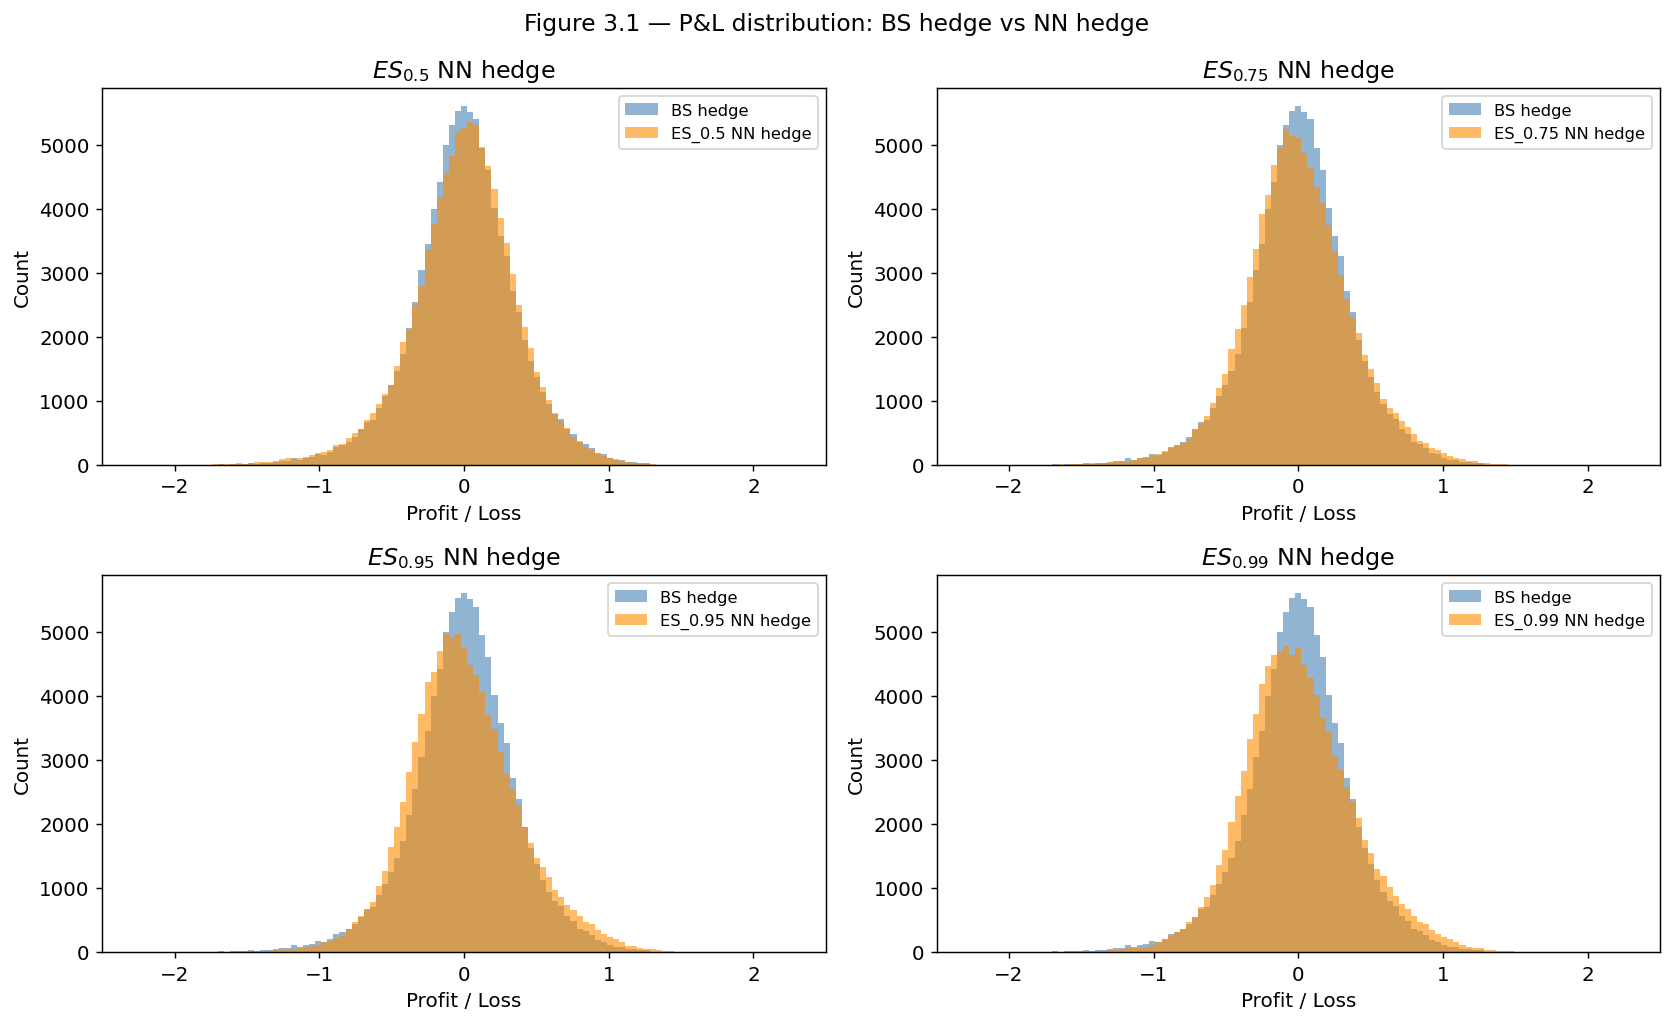

In [17]:
# ---- Figure 3.1 ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, alpha in zip(axes.flat, ALPHAS):
    pl_nn  = nn_pls[alpha].numpy()
    pl_bs_ = pl_bs.numpy()
    xlim   = (-2.5, 2.5)
    bins   = np.linspace(*xlim, 120)

    ax.hist(pl_bs_,  bins=bins, alpha=0.6, color='steelblue', label='BS hedge',     density=False)
    ax.hist(pl_nn,   bins=bins, alpha=0.6, color='darkorange', label=f'ES_{alpha} NN hedge', density=False)
    ax.set_xlim(xlim)
    ax.set_xlabel('Profit / Loss')
    ax.set_ylabel('Count')
    ax.set_title(f'$ES_{{{alpha}}}$ NN hedge')
    ax.legend(fontsize=9)

fig.suptitle('Figure 3.1 — P&L distribution: BS hedge vs NN hedge', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'buehler_figure31.png', bbox_inches='tight')
plt.show()

## Figure 6 & 7 — Buehler et al. (2019)
Compare **50%-CVaR** vs **99%-CVaR** optimality criterion.

* **Figure 6** (raw): P&L loss distribution `−P&L = C_T − PnL − p0_bs` for each network.
* **Figure 7** (normalised): same quantity divided by the risk-neutral price `p0_bs`, plus a summary table.

Key insight: 99%-CVaR compresses the left tail at the cost of a higher mean loss; 50%-CVaR minimises the mean but leaves extreme losses larger.

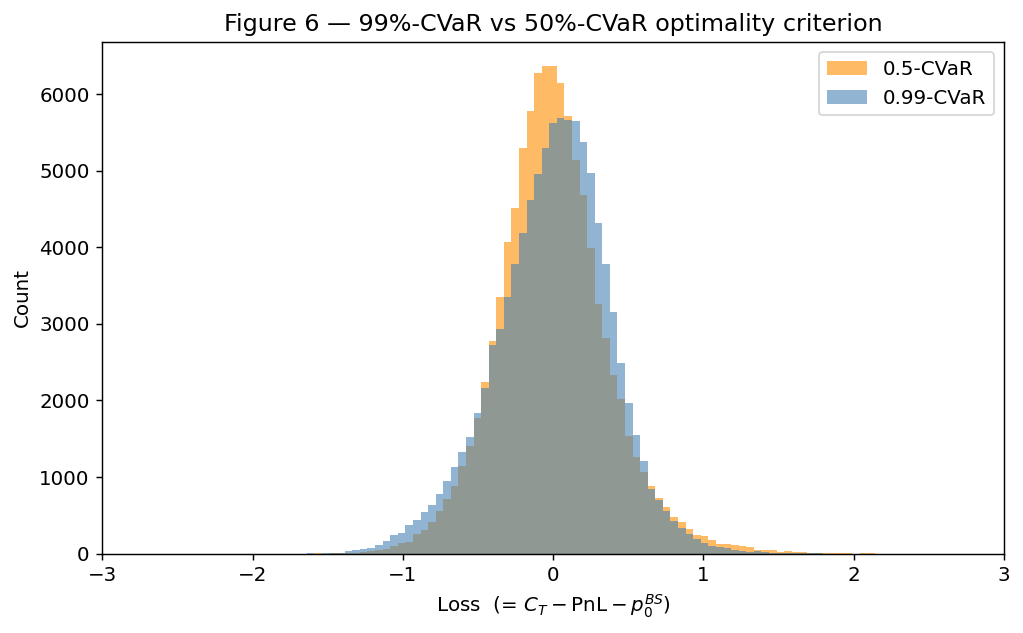

In [9]:
# ---- Figure 6: raw loss distribution ----
# Loss from seller's perspective using BS premium:
#   loss = C_T - PnL - p0_bs  =  -(p0_bs + PnL - C_T)  =  -pl[alpha]
# Positive loss = seller is worse off; negative = seller pocketed a surplus.

loss_50  = -nn_pls[0.5].numpy()
loss_99  = -nn_pls[0.99].numpy()

xlim = (-3.0, 3.0)
bins = np.linspace(*xlim, 120)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(loss_50, bins=bins, alpha=0.6, color='darkorange', label='0.5-CVaR', density=False)
ax.hist(loss_99, bins=bins, alpha=0.6, color='steelblue',  label='0.99-CVaR', density=False)
ax.set_xlim(xlim)
ax.set_xlabel('Loss  (= $C_T - \\mathrm{PnL} - p_0^{BS}$)')
ax.set_ylabel('Count')
ax.set_title('Figure 6 — 99%-CVaR vs 50%-CVaR optimality criterion')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'buehler_figure6.png', bbox_inches='tight')
plt.show()

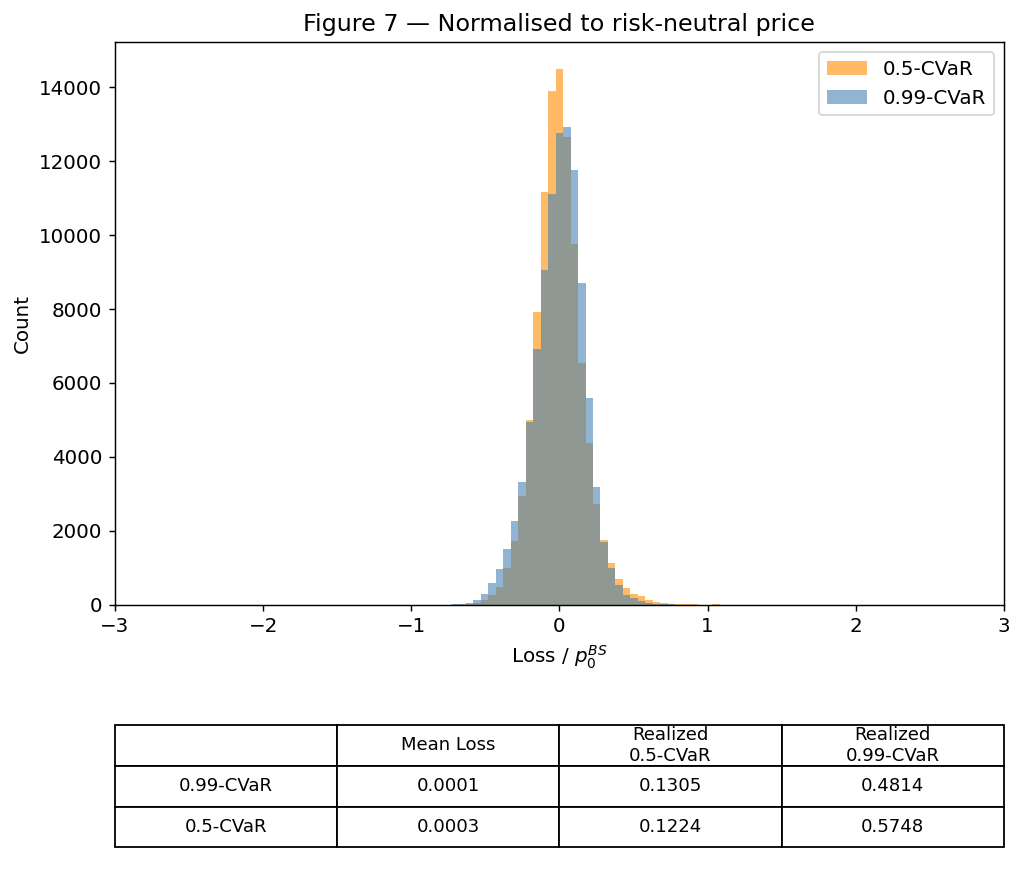

               Mean Loss   Real.0.5-CVaR   Real.0.99-CVaR
----------------------------------------------------------
    0.5-CVaR      0.0003          0.1224           0.5748
   0.99-CVaR      0.0001          0.1305           0.4814


In [10]:
# ---- Figure 7: normalised loss + summary table ----
# Normalise by the risk-neutral (BS) price so values are in units of p0_bs.

def realized_cvar(loss_arr, alpha):
    """ES_α = E[loss | loss > VaR_α(loss)]."""
    var = np.quantile(loss_arr, alpha)
    tail = loss_arr[loss_arr > var]
    return tail.mean() if len(tail) > 0 else var

norm_loss_50  = loss_50  / p0_bs
norm_loss_99  = loss_99  / p0_bs

xlim_n = (-3.0, 3.0)
bins_n = np.linspace(*xlim_n, 120)

fig, (ax_hist, ax_table) = plt.subplots(
    2, 1, figsize=(8, 7),
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_hist.hist(norm_loss_50, bins=bins_n, alpha=0.6, color='darkorange', label='0.5-CVaR', density=False)
ax_hist.hist(norm_loss_99, bins=bins_n, alpha=0.6, color='steelblue',  label='0.99-CVaR', density=False)
ax_hist.set_xlim(xlim_n)
ax_hist.set_xlabel('Loss / $p_0^{BS}$')
ax_hist.set_ylabel('Count')
ax_hist.set_title('Figure 7 — Normalised to risk-neutral price')
ax_hist.legend()

# Summary table
rows   = ['0.99-CVaR', '0.5-CVaR']
losses = [norm_loss_99, norm_loss_50]
col_labels = ['', 'Mean Loss', 'Realized\n0.5-CVaR', 'Realized\n0.99-CVaR']
table_data = [
    [rows[i],
     f'{losses[i].mean():.4f}',
     f'{realized_cvar(losses[i], 0.5):.4f}',
     f'{realized_cvar(losses[i], 0.99):.4f}']
    for i in range(2)
]

ax_table.axis('off')
tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'buehler_figure7.png', bbox_inches='tight')
plt.show()

# Also print the table
print(f"{'':>12}  {'Mean Loss':>10}  {'Real.0.5-CVaR':>14}  {'Real.0.99-CVaR':>15}")
print('-' * 58)
for label, arr in [('0.5-CVaR', norm_loss_50), ('0.99-CVaR', norm_loss_99)]:
    print(f"{label:>12}  {arr.mean():>10.4f}  {realized_cvar(arr, 0.5):>14.4f}  {realized_cvar(arr, 0.99):>15.4f}")